In [ ]:
import os
import kagglehub
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

/home/jcsf/miniconda3/envs/COMP372Assignments/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Download the Iris dataset using `kagglehub`.

In [3]:
IRIS_FOLDER = kagglehub.dataset_download("uciml/iris")
IRIS_CSV=os.path.join(IRIS_FOLDER, "Iris.csv")
RANDOM_STATE = 42

In [4]:
df = pd.read_csv(IRIS_CSV)
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


Separate the features (X) from the labels (y). As per requested from the assignment, we define the training, validation and test set with 70/15/15 split (X_train, y_train, X_val, y_val, X_test, y_test)

In [5]:
X = df.drop(columns=["Id", "Species"]).values
y = df["Species"].values
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

Train the decision tree using `X_train` and `y_train`.

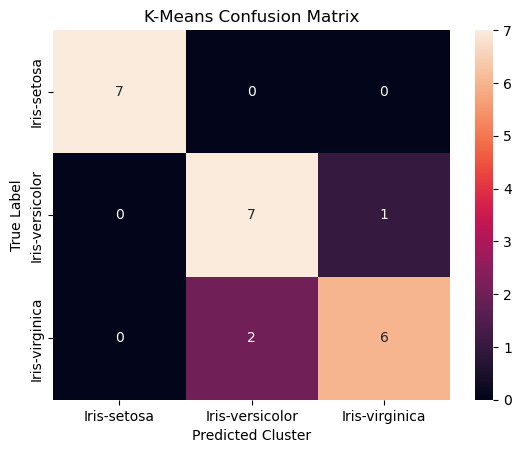

In [6]:
dt = DecisionTreeClassifier(criterion="entropy", random_state=RANDOM_STATE)
dt.fit(X_train, y_train)

predictions = dt.predict(X_test)
cm = confusion_matrix(y_test, predictions, labels=dt.classes_)

sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=dt.classes_,
            yticklabels=dt.classes_)
plt.xlabel('Predicted Cluster')
plt.ylabel('True Label')
plt.title('K-Means Confusion Matrix')
plt.show()


In [8]:
acc = accuracy_score(y_test, predictions)
print(f"Accuracy score: {acc*100}%")

Accuracy score: 86.95652173913044%


Plot the decision tree

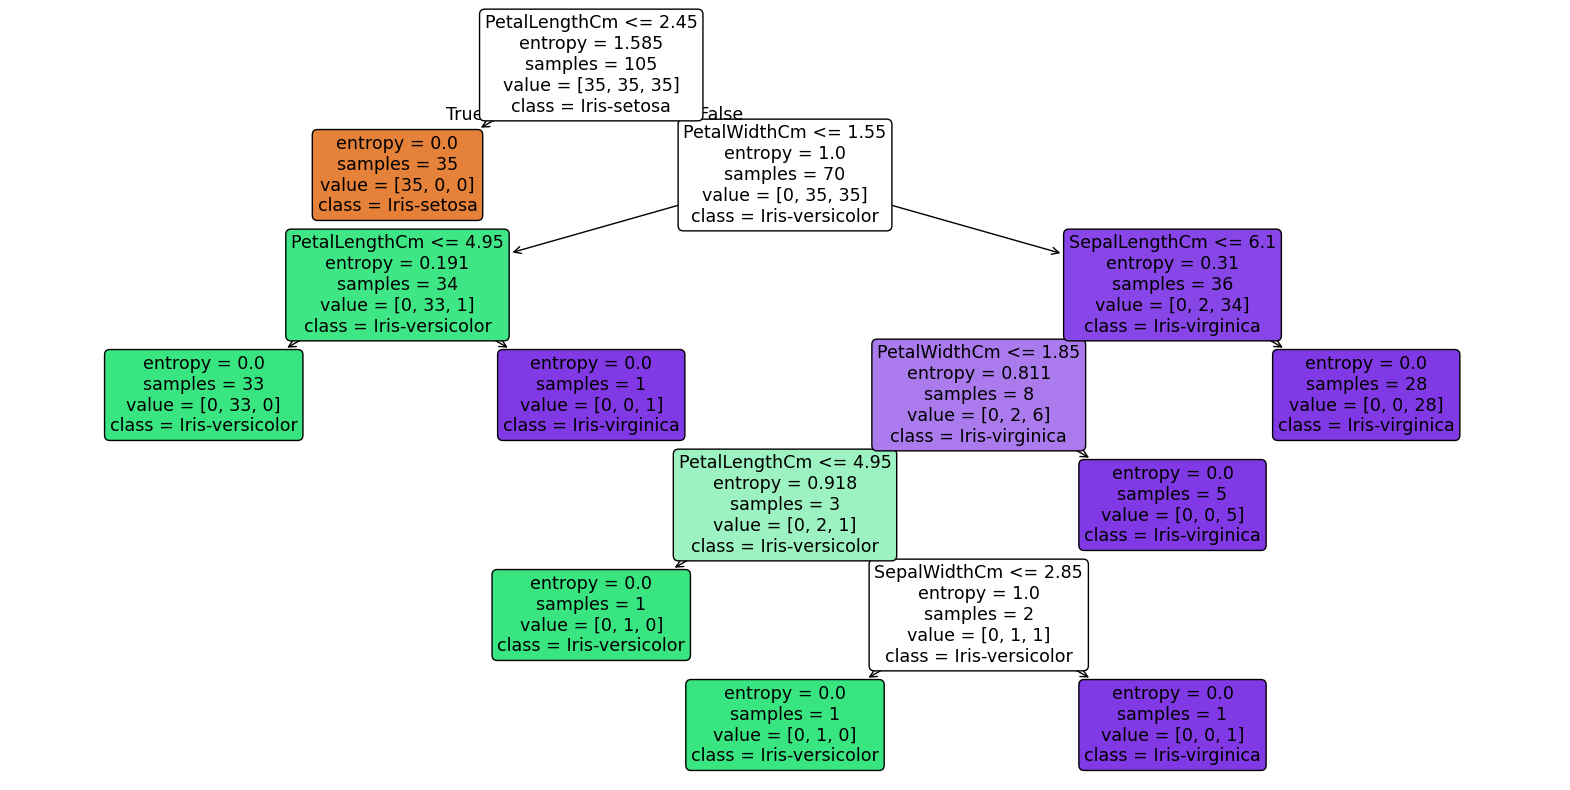

In [9]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=df.drop(columns=["Id", "Species"]).columns, class_names=dt.classes_, 
          filled=True, rounded=True)
plt.show()